# T1_03 — Transformer Encoder (OHLCV structured, 1D, full)

Reglas fuente de verdad: `experimentos_v3/readme_experimentos_v3.md` y `experimentos_v3/PLANNING.md`.

Objetivo (Task B): predecir **OHLCV(t+1)** usando una formulación **estructurada** para forzar velas coherentes.

Componentes (t+1):
- `gap_open = log(open(t+1) / close(t))`
- `logret_close = log(close(t+1) / close(t))`
- `high_excess = log1p(max(high(t+1) - max(open(t+1), close(t+1)), 0))`
- `low_excess = log1p(max(min(open(t+1), close(t+1)) - low(t+1), 0))`
- `logvol = log1p(volume(t+1))`

Reconstrucción:
- `open_hat = close(t) * exp(gap_open_hat)`
- `close_hat = close(t) * exp(logret_close_hat)`
- `high_hat = max(open_hat, close_hat) + expm1(high_excess_hat)`
- `low_hat = min(open_hat, close_hat) - expm1(low_excess_hat)`
- `vol_hat = max(expm1(logvol_hat), 0)`

## 1) Imports

In [1]:
from __future__ import annotations

import json
import math
import random
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

## 2) Paths y configuración

In [2]:
def to_relative(path: Path, root: Path) -> str:
    try:
        return str(path.relative_to(root))
    except ValueError:
        return str(path)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "experimentos_v3").exists():
            return p
    raise FileNotFoundError("No se encontró el root del proyecto (esperado: carpetas 'data' y 'experimentos_v3')")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

DATASET_NAME = "full"
TASK_NAME = "ohlcv"
MODEL_NAME = "T1_03_transformer_encoder_structured"

DATASET_PATH = DATA_DIR / f"btc_1d_features__{DATASET_NAME}.csv"
SPLIT_PATH = DATA_DIR / "_splits" / "splits_1d_walkforward_v3_holdout_from_2025_06.json"

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOOKBACK = 60
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 3
FF_DIM = 128
DROPOUT = 0.2

LR = 1e-4
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 256
MAX_EPOCHS = 60
MIN_EPOCHS = 10
PATIENCE = 12
MIN_DELTA = 1e-4

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = DATA_DIR / "_experiments" / TASK_NAME / MODEL_NAME / DATASET_NAME / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)

{
    "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
    "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
    "out_dir": to_relative(OUT_DIR, PROJECT_ROOT),
    "device": str(DEVICE),
    "seed": SEED,
    "lookback": LOOKBACK,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "ff_dim": FF_DIM,
    "dropout": DROPOUT,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
}

{'dataset_path': 'data/btc_1d_features__full.csv',
 'split_path': 'data/_splits/splits_1d_walkforward_v3_holdout_from_2025_06.json',
 'out_dir': 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328',
 'device': 'cpu',
 'seed': 42,
 'lookback': 60,
 'd_model': 64,
 'n_heads': 4,
 'n_layers': 3,
 'ff_dim': 128,
 'dropout': 0.2,
 'lr': 0.0001,
 'weight_decay': 0.0005,
 'batch_size': 256,
 'max_epochs': 60,
 'patience': 12}

## 3) Cargar dataset y definir targets (structured components)

In [3]:
df = pd.read_csv(DATASET_PATH)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=False)
elif "timestamp" in df.columns:
    df["date"] = pd.to_datetime(df["timestamp"], utc=False)
else:
    raise ValueError("Dataset debe incluir columna 'date' o 'timestamp'")

df = df.sort_values("date").reset_index(drop=True)

required_cols = ["date", "open", "high", "low", "close", "volume"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Falta columna requerida: {c}")

df["close_t"] = df["close"].astype(float)

df["y_true_open_t1"] = df["open"].shift(-1)
df["y_true_high_t1"] = df["high"].shift(-1)
df["y_true_low_t1"] = df["low"].shift(-1)
df["y_true_close_t1"] = df["close"].shift(-1)
df["y_true_volume_t1"] = df["volume"].shift(-1)

open_t1 = df["y_true_open_t1"].to_numpy(dtype=float)
high_t1 = df["y_true_high_t1"].to_numpy(dtype=float)
low_t1 = df["y_true_low_t1"].to_numpy(dtype=float)
close_t1 = df["y_true_close_t1"].to_numpy(dtype=float)
close_t = df["close_t"].to_numpy(dtype=float)
vol_t1 = df["y_true_volume_t1"].to_numpy(dtype=float)

gap_open = np.log(np.maximum(open_t1, 1e-12) / np.maximum(close_t, 1e-12))
logret_close = np.log(np.maximum(close_t1, 1e-12) / np.maximum(close_t, 1e-12))
body_max = np.maximum(open_t1, close_t1)
body_min = np.minimum(open_t1, close_t1)
high_excess = np.log1p(np.maximum(high_t1 - body_max, 0.0))
low_excess = np.log1p(np.maximum(body_min - low_t1, 0.0))
logvol = np.log1p(np.maximum(vol_t1, 0.0))

df["y_gap_open_t1"] = gap_open
df["y_logret_close_t1"] = logret_close
df["y_high_excess_t1"] = high_excess
df["y_low_excess_t1"] = low_excess
df["y_logvol_t1"] = logvol

df = df.dropna(
    subset=[
        "y_true_open_t1",
        "y_true_high_t1",
        "y_true_low_t1",
        "y_true_close_t1",
        "y_true_volume_t1",
        "y_gap_open_t1",
        "y_logret_close_t1",
        "y_high_excess_t1",
        "y_low_excess_t1",
        "y_logvol_t1",
        "close_t",
    ]
).copy()

df[["date", "close_t", "y_true_open_t1", "y_true_close_t1", "y_gap_open_t1", "y_logret_close_t1"]].head(3)

,date,close_t,y_true_open_t1,y_true_close_t1,y_gap_open_t1,y_logret_close_t1
0,2018-02-01 00:00:00+00:00,9010.210912,9010.210912,8810.238040,0.0,-0.022444
1,2018-02-02 00:00:00+00:00,8810.238040,8810.238040,9225.860000,0.0,0.046096
2,2018-02-03 00:00:00+00:00,9225.860000,9225.860000,8191.321445,0.0,-0.118935


## 4) Split oficial (walk-forward + holdout)

In [4]:
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split = json.load(f)


@dataclass(frozen=True)
class Period:
    name: str
    train_start: pd.Timestamp
    train_end: pd.Timestamp
    val_start: pd.Timestamp
    val_end: pd.Timestamp


def _ts(x: str) -> pd.Timestamp:
    t = pd.to_datetime(x)
    if t.tzinfo is None:
        t = t.tz_localize("UTC")
    return t


wf_folds = split.get("folds") or split.get("walk_forward_folds") or []

folds = []
for i, f in enumerate(wf_folds):
    name = f.get("name")
    if name is None:
        name = f"fold_{i + 1}"
    folds.append(
        Period(
            name=name,
            train_start=_ts(f["train"]["start"]),
            train_end=_ts(f["train"]["end"]),
            val_start=_ts(f["val"]["start"]),
            val_end=_ts(f["val"]["end"]),
        )
    )

holdout = split.get("holdout") or split.get("final_holdout")
if holdout is None:
    raise KeyError("Split JSON debe incluir 'holdout' o 'final_holdout'")

holdout_start = _ts(holdout["start"])
holdout_end = _ts(holdout["end"])

len(folds), folds[0], (holdout_start, holdout_end)

(5,
 Period(name='fold_1', train_start=Timestamp('2014-11-10 00:00:00+0000', tz='UTC'), train_end=Timestamp('2019-12-31 23:59:59+0000', tz='UTC'), val_start=Timestamp('2020-01-01 00:00:00+0000', tz='UTC'), val_end=Timestamp('2020-12-31 23:59:59+0000', tz='UTC')),
 (Timestamp('2025-06-01 00:00:00+0000', tz='UTC'),
  Timestamp('2026-03-15 00:00:00+0000', tz='UTC')))

## 5) Utilidades (métricas, secuencias, reconstrucción, modelo)

In [5]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def invalid_candle_rate(open_: np.ndarray, high: np.ndarray, low: np.ndarray, close: np.ndarray) -> float:
    open_ = open_.astype(float)
    high = high.astype(float)
    low = low.astype(float)
    close = close.astype(float)
    m1 = high < np.maximum(open_, close)
    m2 = low > np.minimum(open_, close)
    m3 = low > high
    invalid = m1 | m2 | m3
    return float(np.mean(invalid))


def invalid_volume_rate(volume: np.ndarray) -> float:
    volume = volume.astype(float)
    return float(np.mean(volume < 0))


def compute_metrics_ohlcv(y_true: dict, y_pred: dict) -> dict:
    out = {}
    for k in ["open", "high", "low", "close", "volume"]:
        out[f"MAE_{k}"] = mae(y_true[k], y_pred[k])
        out[f"RMSE_{k}"] = rmse(y_true[k], y_pred[k])

    mean_true = (y_true["open"] + y_true["high"] + y_true["low"] + y_true["close"]) / 4.0
    mean_pred = (y_pred["open"] + y_pred["high"] + y_pred["low"] + y_pred["close"]) / 4.0
    out["MAE_mean_ohlc"] = mae(mean_true, mean_pred)
    out["RMSE_mean_ohlc"] = rmse(mean_true, mean_pred)

    out["invalid_candle_rate_pred"] = invalid_candle_rate(
        open_=y_pred["open"],
        high=y_pred["high"],
        low=y_pred["low"],
        close=y_pred["close"],
    )
    out["invalid_volume_rate_pred"] = invalid_volume_rate(y_pred["volume"])
    return out


def reconstruct_ohlcv_from_components(close_t: np.ndarray, comps: np.ndarray) -> np.ndarray:
    close_t = np.asarray(close_t, dtype=float).reshape(-1)
    comps = np.asarray(comps, dtype=float)

    gap_open = comps[:, 0]
    logret_close = comps[:, 1]
    high_excess = comps[:, 2]
    low_excess = comps[:, 3]
    logvol = comps[:, 4]

    pred_open = close_t * np.exp(gap_open)
    pred_close = close_t * np.exp(logret_close)

    body_max = np.maximum(pred_open, pred_close)
    body_min = np.minimum(pred_open, pred_close)

    pred_high = body_max + np.expm1(high_excess)
    pred_low = body_min - np.expm1(low_excess)
    pred_vol = np.maximum(np.expm1(logvol), 0.0)

    return np.column_stack([pred_open, pred_high, pred_low, pred_close, pred_vol]).astype(float)


def slice_by_date(df: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    m = (df["date"] >= start) & (df["date"] <= end)
    return df.loc[m].copy()


def build_sequences(
    df_all: pd.DataFrame,
    hist_start: pd.Timestamp,
    hist_end: pd.Timestamp,
    pred_start: pd.Timestamp,
    pred_end: pd.Timestamp,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    lookback: int,
    feature_cols: list[str],
) -> dict[str, np.ndarray]:
    d = slice_by_date(df_all, hist_start, hist_end).reset_index(drop=True)

    X_raw = d[feature_cols].to_numpy(dtype=float)
    y_raw = np.column_stack(
        [
            d["y_gap_open_t1"].to_numpy(dtype=float),
            d["y_logret_close_t1"].to_numpy(dtype=float),
            d["y_high_excess_t1"].to_numpy(dtype=float),
            d["y_low_excess_t1"].to_numpy(dtype=float),
            d["y_logvol_t1"].to_numpy(dtype=float),
        ]
    )

    X = x_scaler.transform(X_raw).astype(np.float32)
    y = y_scaler.transform(y_raw).astype(np.float32)

    dates = d["date"].to_numpy()
    close_t = d["close_t"].to_numpy(dtype=float)
    y_true_open = d["y_true_open_t1"].to_numpy(dtype=float)
    y_true_high = d["y_true_high_t1"].to_numpy(dtype=float)
    y_true_low = d["y_true_low_t1"].to_numpy(dtype=float)
    y_true_close = d["y_true_close_t1"].to_numpy(dtype=float)
    y_true_volume = d["y_true_volume_t1"].to_numpy(dtype=float)

    pred_mask = (d["date"] >= pred_start) & (d["date"] <= pred_end)

    X_seq = []
    y_seq = []
    m_date = []
    m_close_t = []
    m_y_true_open = []
    m_y_true_high = []
    m_y_true_low = []
    m_y_true_close = []
    m_y_true_volume = []
    for i in range(lookback - 1, len(d)):
        if not bool(pred_mask.iloc[i]):
            continue
        X_seq.append(X[i - lookback + 1 : i + 1])
        y_seq.append(y[i])
        m_date.append(dates[i])
        m_close_t.append(close_t[i])
        m_y_true_open.append(y_true_open[i])
        m_y_true_high.append(y_true_high[i])
        m_y_true_low.append(y_true_low[i])
        m_y_true_close.append(y_true_close[i])
        m_y_true_volume.append(y_true_volume[i])

    return {
        "X_seq": np.asarray(X_seq, dtype=np.float32),
        "y_seq": np.asarray(y_seq, dtype=np.float32),
        "date": np.asarray(m_date),
        "close_t": np.asarray(m_close_t, dtype=float),
        "y_true_open": np.asarray(m_y_true_open, dtype=float),
        "y_true_high": np.asarray(m_y_true_high, dtype=float),
        "y_true_low": np.asarray(m_y_true_low, dtype=float),
        "y_true_close": np.asarray(m_y_true_close, dtype=float),
        "y_true_volume": np.asarray(m_y_true_volume, dtype=float),
    }


class SeqDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, y_seq: np.ndarray):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y_seq, dtype=torch.float32)

    def __len__(self) -> int:
        return int(self.X.shape[0])

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=float(dropout))

        pe = torch.zeros(int(max_len), int(d_model))
        position = torch.arange(0, int(max_len), dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, int(d_model), 2, dtype=torch.float32) * (-math.log(10000.0) / float(d_model)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class TransformerEncoderRegressor(nn.Module):
    def __init__(
        self,
        n_features: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        ff_dim: int,
        dropout: float,
        out_dim: int,
    ):
        super().__init__()
        self.in_proj = nn.Linear(int(n_features), int(d_model))
        self.pos = PositionalEncoding(d_model=int(d_model), dropout=float(dropout), max_len=5000)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=int(d_model),
            nhead=int(n_heads),
            dim_feedforward=int(ff_dim),
            dropout=float(dropout),
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))
        self.norm = nn.LayerNorm(int(d_model))
        self.head = nn.Linear(int(d_model), int(out_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h)
        h = self.norm(h)
        last = h[:, -1, :]
        return self.head(last)


def train_model(
    n_features: int,
    out_dim: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    max_epochs: int,
    min_epochs: int,
    patience: int,
    min_delta: float,
    verbose: bool = False,
) -> tuple[nn.Module, dict[str, list[float]]]:
    model = TransformerEncoderRegressor(
        n_features=n_features,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        out_dim=out_dim,
    ).to(device)

    if verbose:
        n_params = sum(p.numel() for p in model.parameters())
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(model)
        print({"n_params": int(n_params), "n_trainable": int(n_trainable)})

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(LR),
        weight_decay=float(WEIGHT_DECAY),
        betas=(0.9, 0.98),
        eps=1e-9,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(1, int(patience // 3)),
    )

    history = {"train_loss": [], "val_loss": [], "lr": []}
    best_val = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, int(max_epochs) + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_losses.append(float(loss.detach().cpu().item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(float(loss.detach().cpu().item()))

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        lr_now = float(optimizer.param_groups[0]["lr"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(lr_now)

        improved = (best_val - val_loss) > float(min_delta)
        if improved:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        scheduler.step(val_loss)

        best_epoch = int(np.argmin(history["val_loss"]) + 1) if len(history["val_loss"]) else None
        print(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "val_loss": float(val_loss),
                "lr": float(lr_now),
                "best": float(best_val),
                "best_epoch": int(best_epoch) if best_epoch is not None else None,
                "bad_epochs": int(bad_epochs),
                "patience": int(patience),
            }
        )

        if epoch >= int(min_epochs) and bad_epochs >= int(patience):
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def predict_scaled(model: nn.Module, X_seq: np.ndarray, device: torch.device, batch_size: int) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X_seq), int(batch_size)):
            xb = torch.tensor(X_seq[i : i + int(batch_size)], dtype=torch.float32, device=device)
            pred = model(xb).detach().cpu().numpy()
            out.append(pred)
    return np.concatenate(out, axis=0)

## 6) Walk-forward folds (Transformer Encoder)

In [6]:
feature_cols = [c for c in df.columns if c not in {
    "date",
    "timestamp",
    "close_t",
    "y_true_open_t1",
    "y_true_high_t1",
    "y_true_low_t1",
    "y_true_close_t1",
    "y_true_volume_t1",
    "y_gap_open_t1",
    "y_logret_close_t1",
    "y_high_excess_t1",
    "y_low_excess_t1",
    "y_logvol_t1",
}]

results = {
    "meta": {
        "task": TASK_NAME,
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "run_id": RUN_ID,
        "dataset_path": to_relative(DATASET_PATH, PROJECT_ROOT),
        "split_path": to_relative(SPLIT_PATH, PROJECT_ROOT),
        "target": "structured: (gap_open, logret_close, high_excess, low_excess, logvol)(t+1) y reconstrucción a OHLCV",
        "n_features": int(len(feature_cols)),
        "feature_cols": feature_cols,
        "seed": int(SEED),
        "device": str(DEVICE),
        "lookback": int(LOOKBACK),
        "model_hparams": {
            "d_model": int(D_MODEL),
            "n_heads": int(N_HEADS),
            "n_layers": int(N_LAYERS),
            "ff_dim": int(FF_DIM),
            "dropout": float(DROPOUT),
        },
        "train_hparams": {
            "lr": float(LR),
            "weight_decay": float(WEIGHT_DECAY),
            "batch_size": int(BATCH_SIZE),
            "max_epochs": int(MAX_EPOCHS),
            "min_epochs": int(MIN_EPOCHS),
            "patience": int(PATIENCE),
            "min_delta": float(MIN_DELTA),
        },
        "scaling": "StandardScaler(X) + StandardScaler(y_components)",
    },
    "folds": [],
    "holdout": None,
}

for p in folds:
    df_train = slice_by_date(df, p.train_start, p.train_end)

    x_scaler = StandardScaler()
    x_scaler.fit(df_train[feature_cols].to_numpy(dtype=float))

    y_scaler = StandardScaler()
    y_train = np.column_stack(
        [
            df_train["y_gap_open_t1"].to_numpy(dtype=float),
            df_train["y_logret_close_t1"].to_numpy(dtype=float),
            df_train["y_high_excess_t1"].to_numpy(dtype=float),
            df_train["y_low_excess_t1"].to_numpy(dtype=float),
            df_train["y_logvol_t1"].to_numpy(dtype=float),
        ]
    )
    y_scaler.fit(y_train)

    train_pack = build_sequences(
        df_all=df,
        hist_start=p.train_start,
        hist_end=p.val_end,
        pred_start=p.train_start,
        pred_end=p.train_end,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        feature_cols=feature_cols,
    )
    val_pack = build_sequences(
        df_all=df,
        hist_start=p.train_start,
        hist_end=p.val_end,
        pred_start=p.val_start,
        pred_end=p.val_end,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        feature_cols=feature_cols,
    )

    ds_train = SeqDataset(train_pack["X_seq"], train_pack["y_seq"])
    ds_val = SeqDataset(val_pack["X_seq"], val_pack["y_seq"])

    train_loader = DataLoader(ds_train, batch_size=int(BATCH_SIZE), shuffle=True, drop_last=False)
    val_loader = DataLoader(ds_val, batch_size=int(BATCH_SIZE), shuffle=False, drop_last=False)

    model, history = train_model(
        n_features=len(feature_cols),
        out_dim=5,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        max_epochs=MAX_EPOCHS,
        min_epochs=MIN_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    y_pred_scaled = predict_scaled(model, val_pack["X_seq"], DEVICE, batch_size=BATCH_SIZE)
    y_pred_components = y_scaler.inverse_transform(y_pred_scaled).astype(float)
    y_pred_ohlcv = reconstruct_ohlcv_from_components(val_pack["close_t"], y_pred_components)

    metrics = compute_metrics_ohlcv(
        y_true={
            "open": val_pack["y_true_open"],
            "high": val_pack["y_true_high"],
            "low": val_pack["y_true_low"],
            "close": val_pack["y_true_close"],
            "volume": val_pack["y_true_volume"],
        },
        y_pred={
            "open": y_pred_ohlcv[:, 0],
            "high": y_pred_ohlcv[:, 1],
            "low": y_pred_ohlcv[:, 2],
            "close": y_pred_ohlcv[:, 3],
            "volume": y_pred_ohlcv[:, 4],
        },
    )

    results["folds"].append(
        {
            "name": p.name,
            "train": {"start": str(p.train_start.date()), "end": str(p.train_end.date())},
            "val": {"start": str(p.val_start.date()), "end": str(p.val_end.date())},
            "n_train_seq": int(len(ds_train)),
            "n_val_seq": int(len(ds_val)),
            "n_epochs": int(len(history["val_loss"])),
            "best_epoch": int(np.argmin(history["val_loss"]) + 1) if len(history["val_loss"]) else None,
            "metrics_ohlcv": metrics,
        }
    )

pd.DataFrame([{"fold": f["name"], **f["metrics_ohlcv"]} for f in results["folds"]]).head(3)

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


{'epoch': 1, 'train_loss': 0.34568620721499127, 'val_loss': 0.4402477741241455, 'lr': 0.0001, 'best': 0.4402477741241455, 'best_epoch': 1, 'bad_epochs': 0, 'patience': 12}
{'epoch': 2, 'train_loss': 0.3162008722623189, 'val_loss': 0.40851742029190063, 'lr': 0.0001, 'best': 0.40851742029190063, 'best_epoch': 2, 'bad_epochs': 0, 'patience': 12}
{'epoch': 3, 'train_loss': 0.2988493740558624, 'val_loss': 0.38011133670806885, 'lr': 0.0001, 'best': 0.38011133670806885, 'best_epoch': 3, 'bad_epochs': 0, 'patience': 12}
{'epoch': 4, 'train_loss': 0.2740369737148285, 'val_loss': 0.35559679567813873, 'lr': 0.0001, 'best': 0.35559679567813873, 'best_epoch': 4, 'bad_epochs': 0, 'patience': 12}
{'epoch': 5, 'train_loss': 0.25986448923746747, 'val_loss': 0.33455806970596313, 'lr': 0.0001, 'best': 0.33455806970596313, 'best_epoch': 5, 'bad_epochs': 0, 'patience': 12}
{'epoch': 6, 'train_loss': 0.2603336771329244, 'val_loss': 0.31743094325065613, 'lr': 0.0001, 'best': 0.31743094325065613, 'best_epoch'

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


{'epoch': 1, 'train_loss': 0.32082224637269974, 'val_loss': 0.4267846345901489, 'lr': 0.0001, 'best': 0.4267846345901489, 'best_epoch': 1, 'bad_epochs': 0, 'patience': 12}
{'epoch': 2, 'train_loss': 0.28613831102848053, 'val_loss': 0.4113103747367859, 'lr': 0.0001, 'best': 0.4113103747367859, 'best_epoch': 2, 'bad_epochs': 0, 'patience': 12}
{'epoch': 3, 'train_loss': 0.26790640130639076, 'val_loss': 0.3962748944759369, 'lr': 0.0001, 'best': 0.3962748944759369, 'best_epoch': 3, 'bad_epochs': 0, 'patience': 12}
{'epoch': 4, 'train_loss': 0.25539280474185944, 'val_loss': 0.3828199952840805, 'lr': 0.0001, 'best': 0.3828199952840805, 'best_epoch': 4, 'bad_epochs': 0, 'patience': 12}
{'epoch': 5, 'train_loss': 0.24730420112609863, 'val_loss': 0.3714264780282974, 'lr': 0.0001, 'best': 0.3714264780282974, 'best_epoch': 5, 'bad_epochs': 0, 'patience': 12}
{'epoch': 6, 'train_loss': 0.24470414593815804, 'val_loss': 0.3616662323474884, 'lr': 0.0001, 'best': 0.3616662323474884, 'best_epoch': 6, '

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


...

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


{'epoch': 1, 'train_loss': 0.3691145522253854, 'val_loss': 0.17810124158859253, 'lr': 0.0001, 'best': 0.17810124158859253, 'best_epoch': 1, 'bad_epochs': 0, 'patience': 12}
{'epoch': 2, 'train_loss': 0.3001081645488739, 'val_loss': 0.17508552223443985, 'lr': 0.0001, 'best': 0.17508552223443985, 'best_epoch': 2, 'bad_epochs': 0, 'patience': 12}
{'epoch': 3, 'train_loss': 0.2647768535784313, 'val_loss': 0.18318960070610046, 'lr': 0.0001, 'best': 0.17508552223443985, 'best_epoch': 2, 'bad_epochs': 1, 'patience': 12}
{'epoch': 4, 'train_loss': 0.24308606343609945, 'val_loss': 0.1890111044049263, 'lr': 0.0001, 'best': 0.17508552223443985, 'best_epoch': 2, 'bad_epochs': 2, 'patience': 12}
{'epoch': 5, 'train_loss': 0.22989875503948756, 'val_loss': 0.18813738971948624, 'lr': 0.0001, 'best': 0.17508552223443985, 'best_epoch': 2, 'bad_epochs': 3, 'patience': 12}
{'epoch': 6, 'train_loss': 0.21949454716273717, 'val_loss': 0.18572860956192017, 'lr': 0.0001, 'best': 0.17508552223443985, 'best_epoc

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


{'epoch': 1, 'train_loss': 0.3566825058725145, 'val_loss': 0.48326483368873596, 'lr': 0.0001, 'best': 0.48326483368873596, 'best_epoch': 1, 'bad_epochs': 0, 'patience': 12}
{'epoch': 2, 'train_loss': 0.2868172393904792, 'val_loss': 0.38502319157123566, 'lr': 0.0001, 'best': 0.38502319157123566, 'best_epoch': 2, 'bad_epochs': 0, 'patience': 12}
{'epoch': 3, 'train_loss': 0.24924950136078727, 'val_loss': 0.33626701682806015, 'lr': 0.0001, 'best': 0.33626701682806015, 'best_epoch': 3, 'bad_epochs': 0, 'patience': 12}
{'epoch': 4, 'train_loss': 0.2358306431108051, 'val_loss': 0.3187768682837486, 'lr': 0.0001, 'best': 0.3187768682837486, 'best_epoch': 4, 'bad_epochs': 0, 'patience': 12}
{'epoch': 5, 'train_loss': 0.22014047702153525, 'val_loss': 0.3130728378891945, 'lr': 0.0001, 'best': 0.3130728378891945, 'best_epoch': 5, 'bad_epochs': 0, 'patience': 12}
{'epoch': 6, 'train_loss': 0.21047766341103447, 'val_loss': 0.3117464855313301, 'lr': 0.0001, 'best': 0.3117464855313301, 'best_epoch': 6

,fold,MAE_open,RMSE_open,MAE_high,RMSE_high,MAE_low,RMSE_low,MAE_close,RMSE_close,MAE_volume,RMSE_volume,MAE_mean_ohlc,RMSE_mean_ohlc,invalid_candle_rate_pred,invalid_volume_rate_pred
0,fold_1,2.498103,3.042569,221.965625,390.799895,192.371689,320.872548,317.129780,483.152374,0.016962,0.043178,168.011633,254.777471,0.0,0.0
1,fold_2,0.827547,1.077724,932.850870,1375.752376,1303.247558,2116.218197,1550.647680,2030.207279,0.013389,0.029208,821.365088,1113.060887,0.0,0.0
2,fold_3,0.755444,1.041678,454.864061,765.305903,507.306152,888.670490,660.065242,1021.499461,0.000000,0.000000,344.294068,531.478307,0.0,0.0


## 7) Entrenamiento final (dev) y evaluación holdout

In [7]:
df_dev_train = slice_by_date(df, folds[0].train_start, folds[-1].train_end)
df_dev_val = slice_by_date(df, folds[-1].val_start, folds[-1].val_end)

x_scaler = StandardScaler()
x_scaler.fit(df_dev_train[feature_cols].to_numpy(dtype=float))

y_scaler = StandardScaler()
y_dev_train = np.column_stack(
    [
        df_dev_train["y_gap_open_t1"].to_numpy(dtype=float),
        df_dev_train["y_logret_close_t1"].to_numpy(dtype=float),
        df_dev_train["y_high_excess_t1"].to_numpy(dtype=float),
        df_dev_train["y_low_excess_t1"].to_numpy(dtype=float),
        df_dev_train["y_logvol_t1"].to_numpy(dtype=float),
    ]
)
y_scaler.fit(y_dev_train)

dev_train_pack = build_sequences(
    df_all=df,
    hist_start=folds[0].train_start,
    hist_end=holdout_end,
    pred_start=folds[0].train_start,
    pred_end=folds[-1].train_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)
dev_val_pack = build_sequences(
    df_all=df,
    hist_start=folds[0].train_start,
    hist_end=holdout_end,
    pred_start=folds[-1].val_start,
    pred_end=folds[-1].val_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)

ds_dev_train = SeqDataset(dev_train_pack["X_seq"], dev_train_pack["y_seq"])
ds_dev_val = SeqDataset(dev_val_pack["X_seq"], dev_val_pack["y_seq"])

dev_train_loader = DataLoader(ds_dev_train, batch_size=int(BATCH_SIZE), shuffle=True, drop_last=False)
dev_val_loader = DataLoader(ds_dev_val, batch_size=int(BATCH_SIZE), shuffle=False, drop_last=False)

model_dev, history_dev = train_model(
    n_features=len(feature_cols),
    out_dim=5,
    train_loader=dev_train_loader,
    val_loader=dev_val_loader,
    device=DEVICE,
    max_epochs=MAX_EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    verbose=True,
)

best_epoch = int(np.argmin(history_dev["val_loss"]) + 1) if len(history_dev["val_loss"]) else None

hold_pack = build_sequences(
    df_all=df,
    hist_start=folds[0].train_start,
    hist_end=holdout_end,
    pred_start=holdout_start,
    pred_end=holdout_end,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    lookback=LOOKBACK,
    feature_cols=feature_cols,
)

y_pred_scaled = predict_scaled(model_dev, hold_pack["X_seq"], DEVICE, batch_size=BATCH_SIZE)
y_pred_components = y_scaler.inverse_transform(y_pred_scaled).astype(float)
y_pred_ohlcv = reconstruct_ohlcv_from_components(hold_pack["close_t"], y_pred_components)

pred_holdout = pd.DataFrame(
    {
        "date": hold_pack["date"],
        "y_true_open_t1": hold_pack["y_true_open"],
        "y_pred_open_t1": y_pred_ohlcv[:, 0],
        "y_true_high_t1": hold_pack["y_true_high"],
        "y_pred_high_t1": y_pred_ohlcv[:, 1],
        "y_true_low_t1": hold_pack["y_true_low"],
        "y_pred_low_t1": y_pred_ohlcv[:, 2],
        "y_true_close_t1": hold_pack["y_true_close"],
        "y_pred_close_t1": y_pred_ohlcv[:, 3],
        "y_true_volume_t1": hold_pack["y_true_volume"],
        "y_pred_volume_t1": y_pred_ohlcv[:, 4],
    }
)

metrics_holdout = compute_metrics_ohlcv(
    y_true={
        "open": pred_holdout["y_true_open_t1"].to_numpy(dtype=float),
        "high": pred_holdout["y_true_high_t1"].to_numpy(dtype=float),
        "low": pred_holdout["y_true_low_t1"].to_numpy(dtype=float),
        "close": pred_holdout["y_true_close_t1"].to_numpy(dtype=float),
        "volume": pred_holdout["y_true_volume_t1"].to_numpy(dtype=float),
    },
    y_pred={
        "open": pred_holdout["y_pred_open_t1"].to_numpy(dtype=float),
        "high": pred_holdout["y_pred_high_t1"].to_numpy(dtype=float),
        "low": pred_holdout["y_pred_low_t1"].to_numpy(dtype=float),
        "close": pred_holdout["y_pred_close_t1"].to_numpy(dtype=float),
        "volume": pred_holdout["y_pred_volume_t1"].to_numpy(dtype=float),
    },
)

results["holdout"] = {
    "period": {"start": str(holdout_start.date()), "end": str(holdout_end.date())},
    "n_holdout": int(len(pred_holdout)),
    "n_epochs_dev": int(len(history_dev["val_loss"])),
    "best_epoch_dev": int(best_epoch) if best_epoch is not None else None,
    "metrics_ohlcv": metrics_holdout,
}

results["holdout"], results["folds"][0]["metrics_ohlcv"]

TransformerEncoderRegressor(
  (in_proj): Linear(in_features=47, out_features=64, bias=True)
  (pos): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=5, bias=True)
)
{'n_p

/var/folders/hx/lgcrbx7x0v3967rm2m9yysyh0000gn/T/ipykernel_34383/2041933994.py:200: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=int(n_layers))


{'epoch': 1, 'train_loss': 0.2961766670147578, 'val_loss': 0.41178324818611145, 'lr': 0.0001, 'best': 0.41178324818611145, 'best_epoch': 1, 'bad_epochs': 0, 'patience': 12}
{'epoch': 2, 'train_loss': 0.2541584240065681, 'val_loss': 0.34499864280223846, 'lr': 0.0001, 'best': 0.34499864280223846, 'best_epoch': 2, 'bad_epochs': 0, 'patience': 12}
{'epoch': 3, 'train_loss': 0.23840814001030392, 'val_loss': 0.32571858167648315, 'lr': 0.0001, 'best': 0.32571858167648315, 'best_epoch': 3, 'bad_epochs': 0, 'patience': 12}
{'epoch': 4, 'train_loss': 0.21931608683533138, 'val_loss': 0.3196994289755821, 'lr': 0.0001, 'best': 0.3196994289755821, 'best_epoch': 4, 'bad_epochs': 0, 'patience': 12}
{'epoch': 5, 'train_loss': 0.2195073796643151, 'val_loss': 0.31808996200561523, 'lr': 0.0001, 'best': 0.31808996200561523, 'best_epoch': 5, 'bad_epochs': 0, 'patience': 12}
{'epoch': 6, 'train_loss': 0.20532585680484772, 'val_loss': 0.3177943229675293, 'lr': 0.0001, 'best': 0.3177943229675293, 'best_epoch':

({'period': {'start': '2025-06-01', 'end': '2026-03-15'},
  'n_holdout': 287,
  'n_epochs_dev': 60,
  'best_epoch_dev': 59,
  'metrics_ohlcv': {'MAE_open': 27.607880419308913,
   'RMSE_open': 27.98890986623561,
   'MAE_high': 1205.240931207166,
   'RMSE_high': 1762.957273996123,
   'MAE_low': 1505.3797558879046,
   'RMSE_low': 2304.6879532495414,
   'MAE_close': 1530.9264611305407,
   'RMSE_close': 2108.1374040762885,
   'MAE_volume': 24992.02856701728,
   'RMSE_volume': 29510.485774974313,
   'MAE_mean_ohlc': 830.7751916507565,
   'RMSE_mean_ohlc': 1142.0311671049014,
   'invalid_candle_rate_pred': 0.0,
   'invalid_volume_rate_pred': 0.0}},
 {'MAE_open': 2.4981031402980416,
  'RMSE_open': 3.042569393354765,
  'MAE_high': 221.96562502181288,
  'RMSE_high': 390.7998952913972,
  'MAE_low': 192.37168852798055,
  'RMSE_low': 320.8725476316563,
  'MAE_close': 317.12978043612924,
  'RMSE_close': 483.1523739209299,
  'MAE_volume': 0.016962008444840467,
  'RMSE_volume': 0.043177842301432616,
 

## 8) Guardar artefactos requeridos

In [8]:
metrics_path = OUT_DIR / "metrics.json"
pred_holdout_path = OUT_DIR / "pred_holdout.csv"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

pred_cols = [
    "date",
    "y_true_open_t1",
    "y_pred_open_t1",
    "y_true_high_t1",
    "y_pred_high_t1",
    "y_true_low_t1",
    "y_pred_low_t1",
    "y_true_close_t1",
    "y_pred_close_t1",
    "y_true_volume_t1",
    "y_pred_volume_t1",
]
pred_holdout[pred_cols].to_csv(pred_holdout_path, index=False)

to_relative(metrics_path, PROJECT_ROOT), to_relative(pred_holdout_path, PROJECT_ROOT)

('data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/metrics.json',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/pred_holdout.csv')

## 9) Figuras requeridas (holdout)

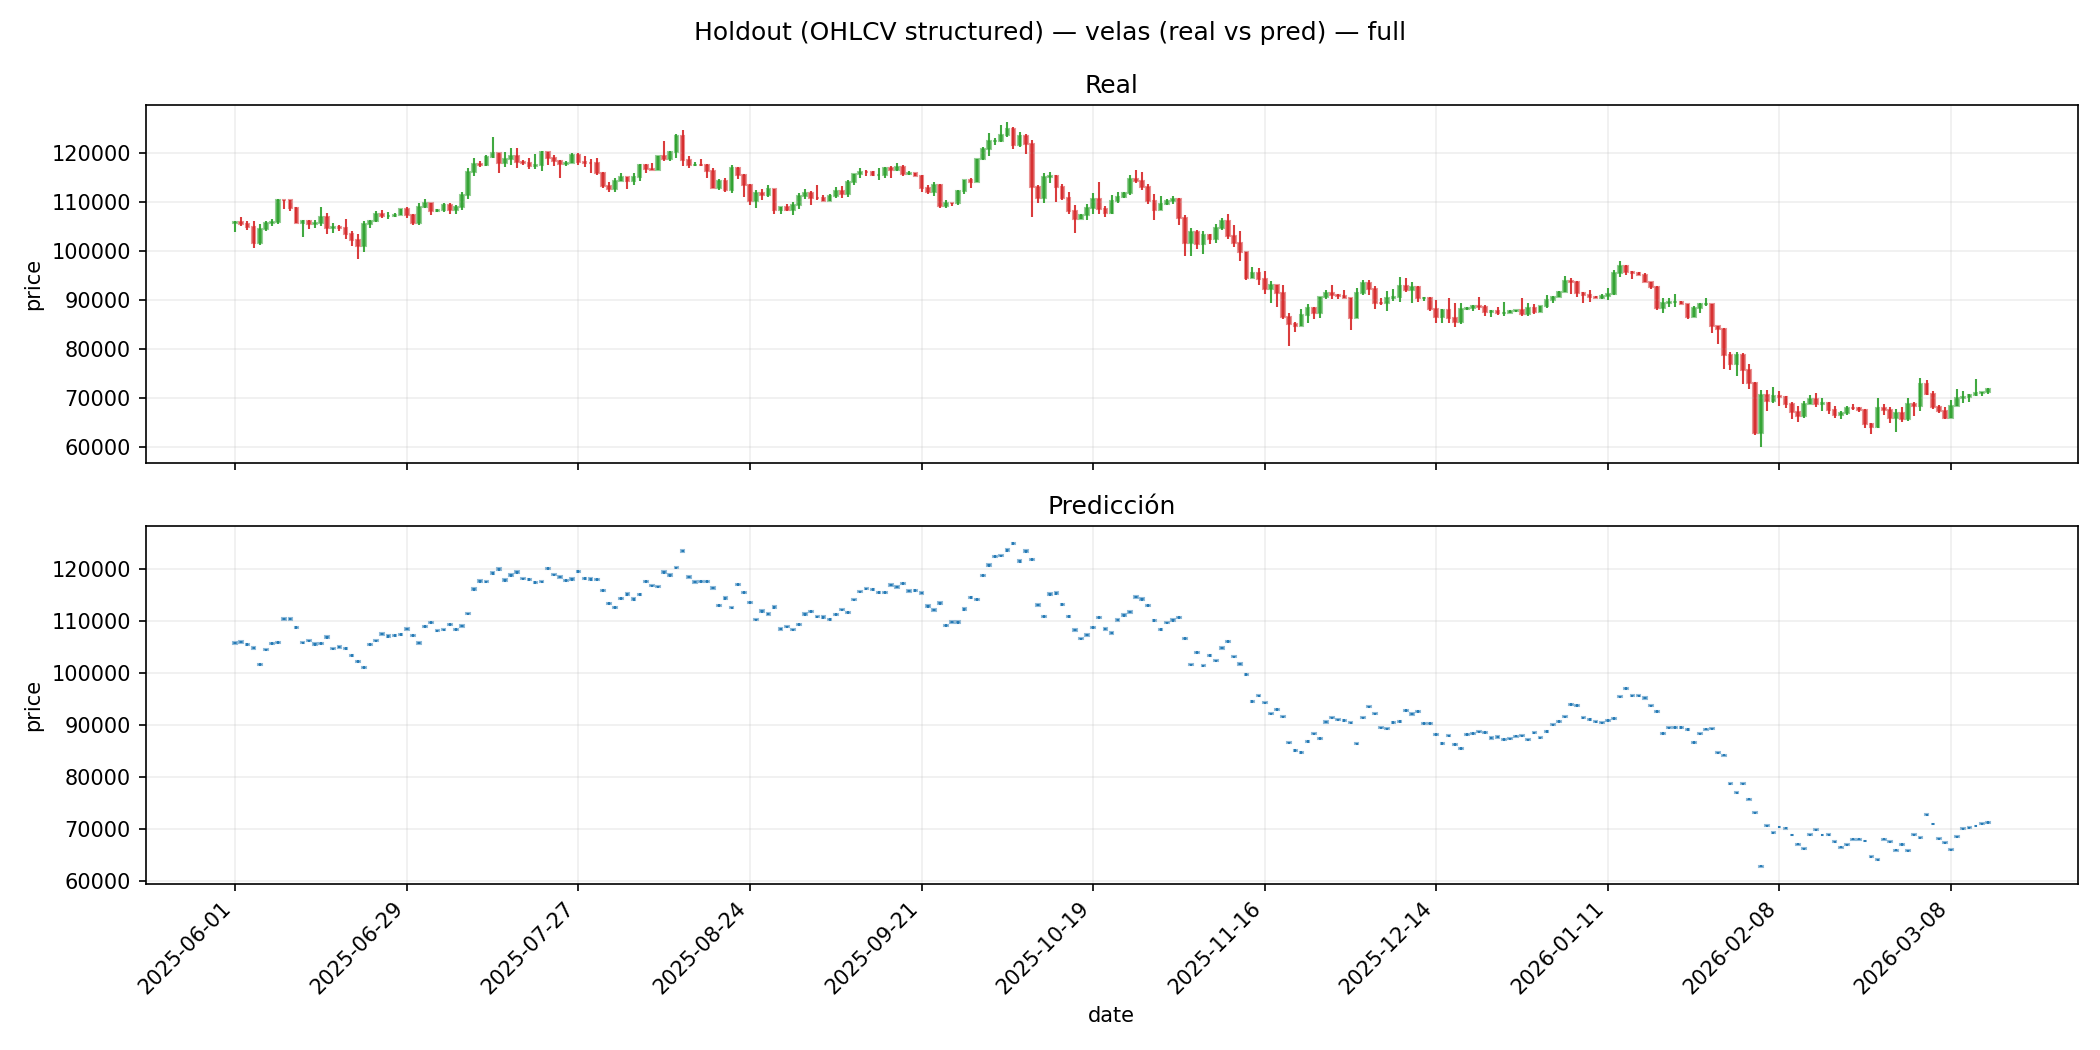

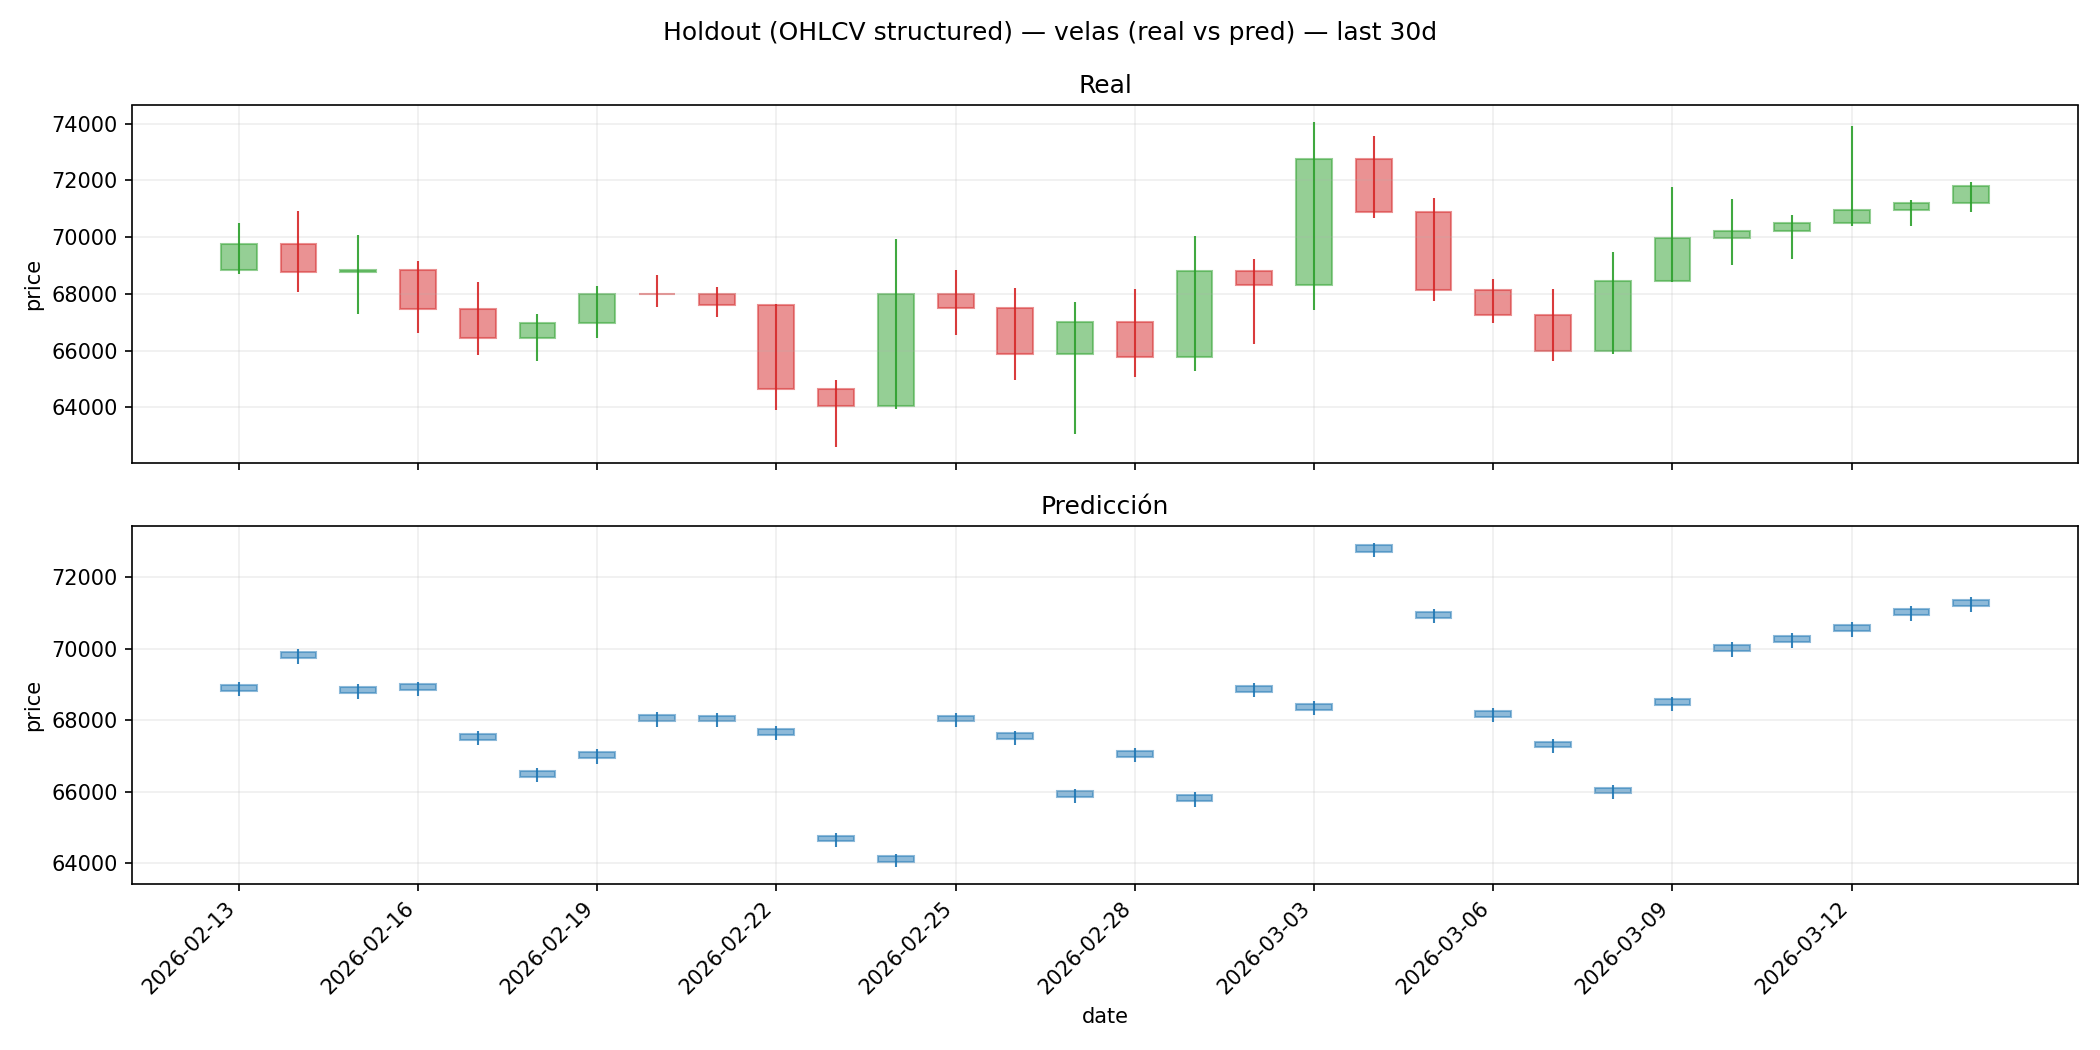

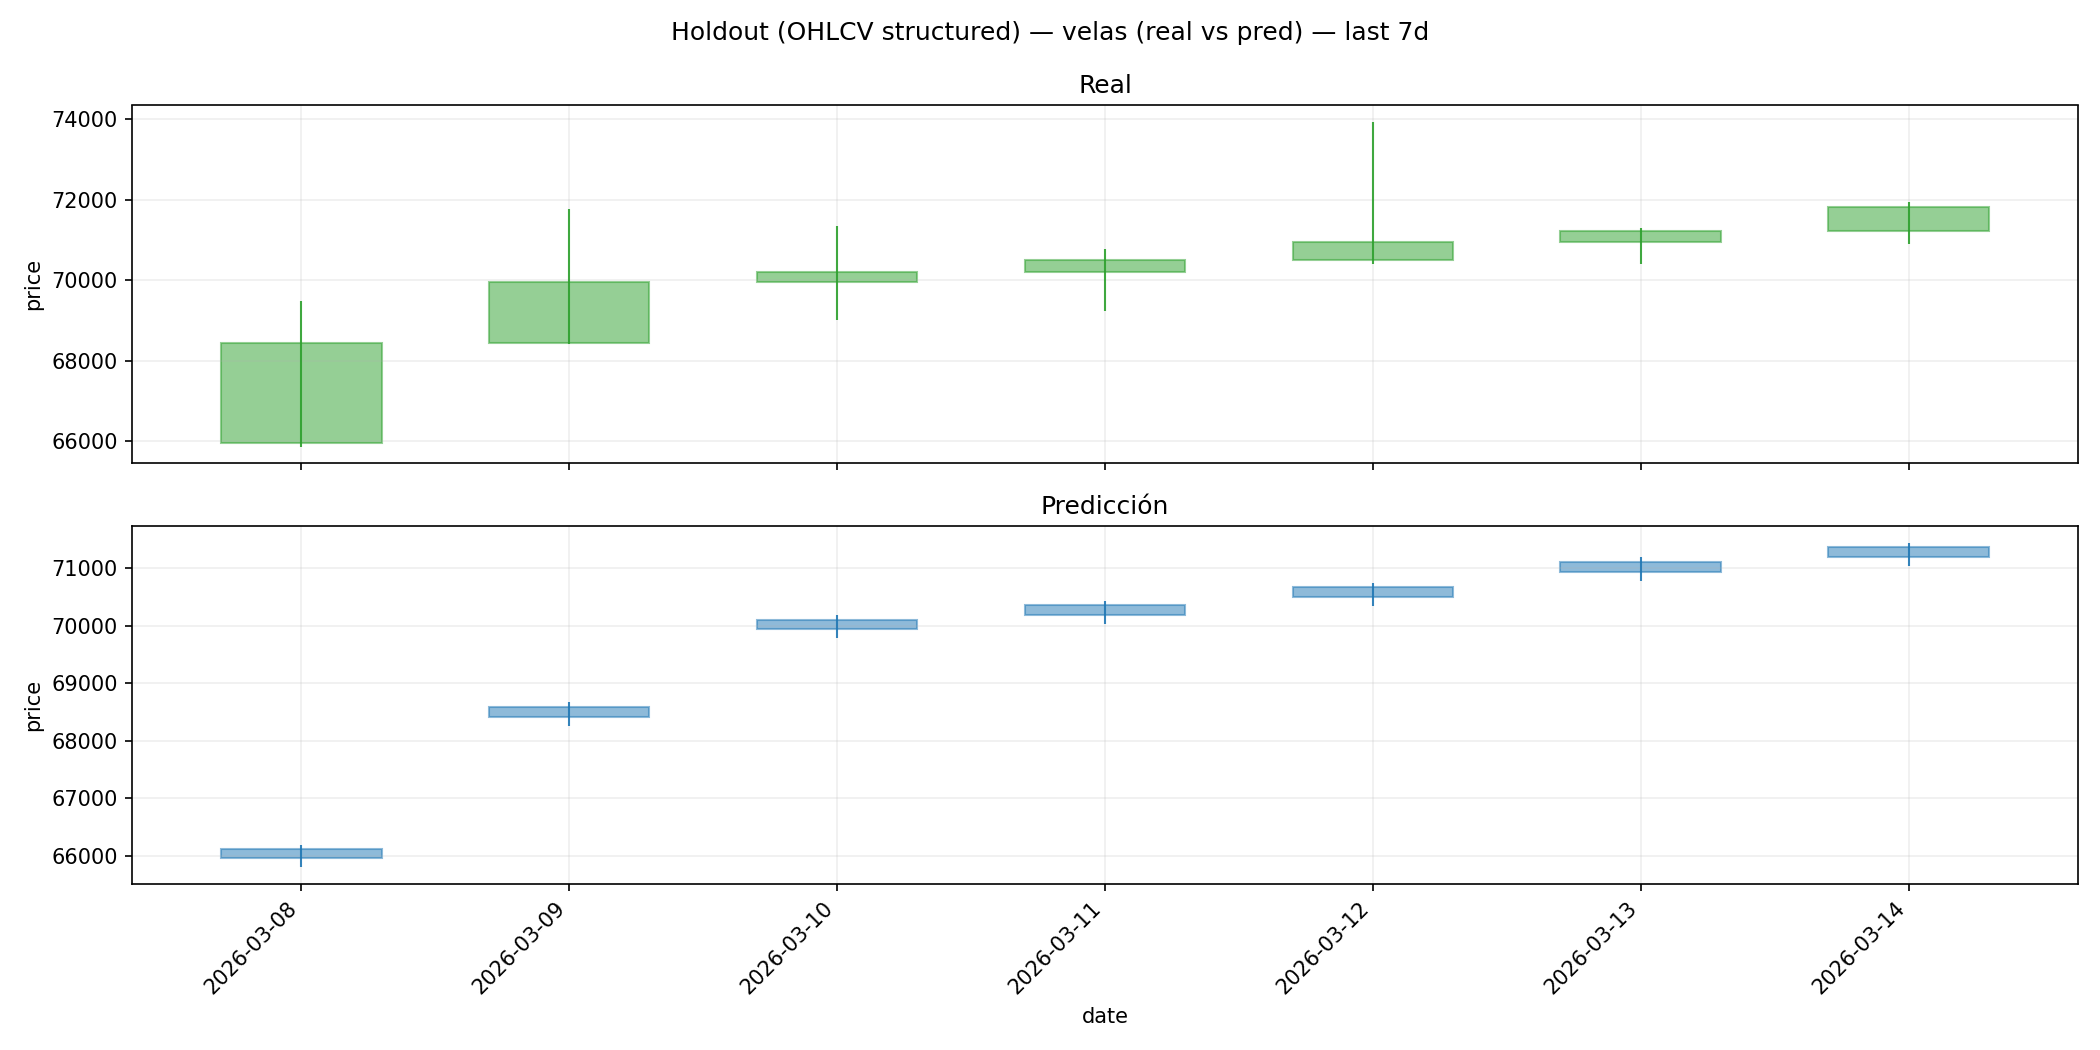

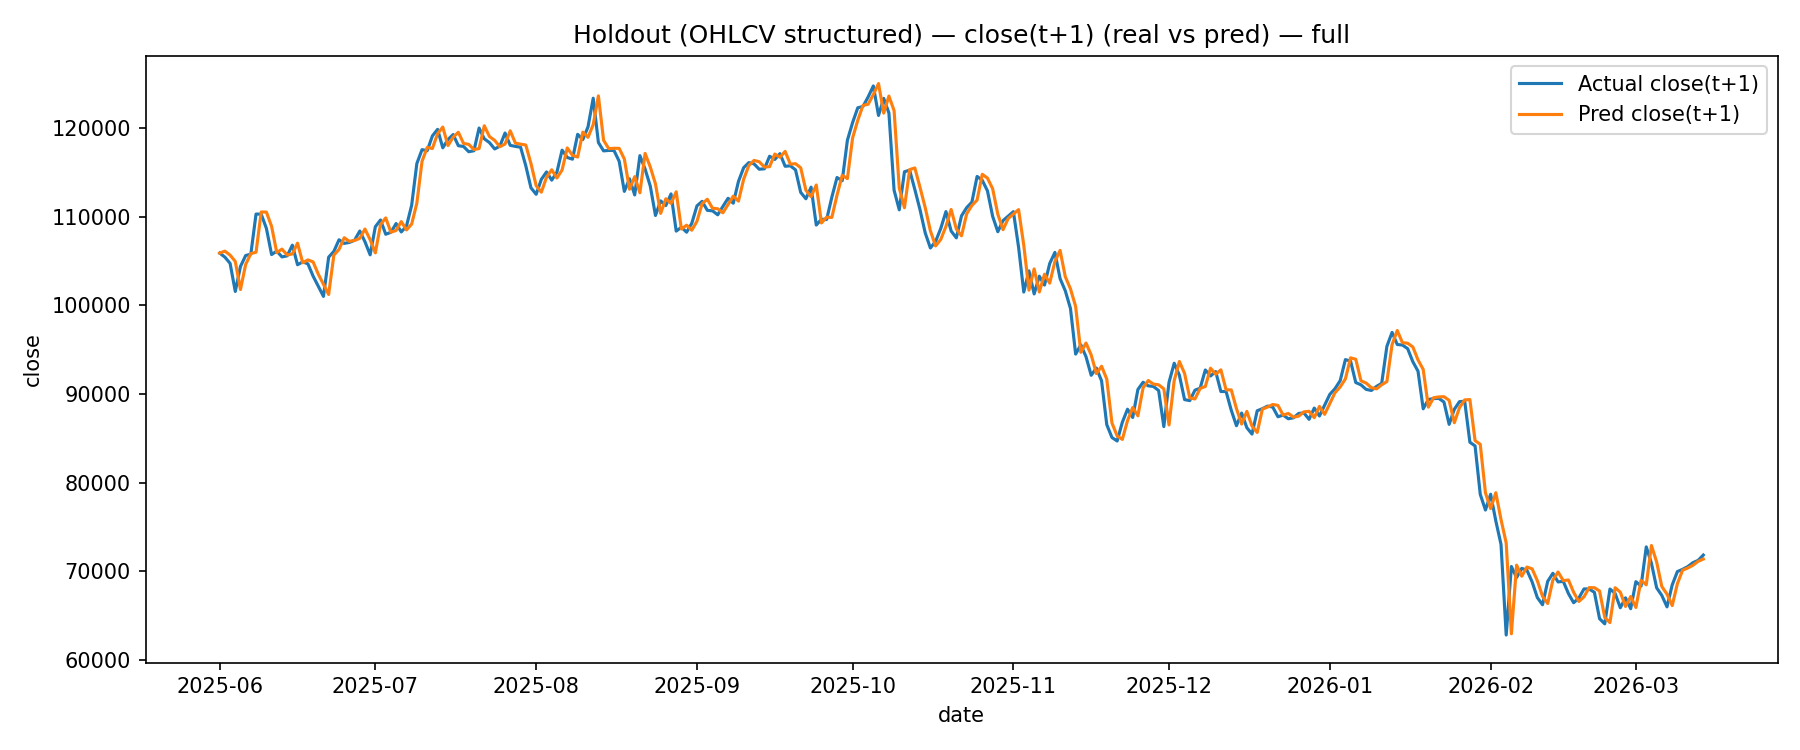

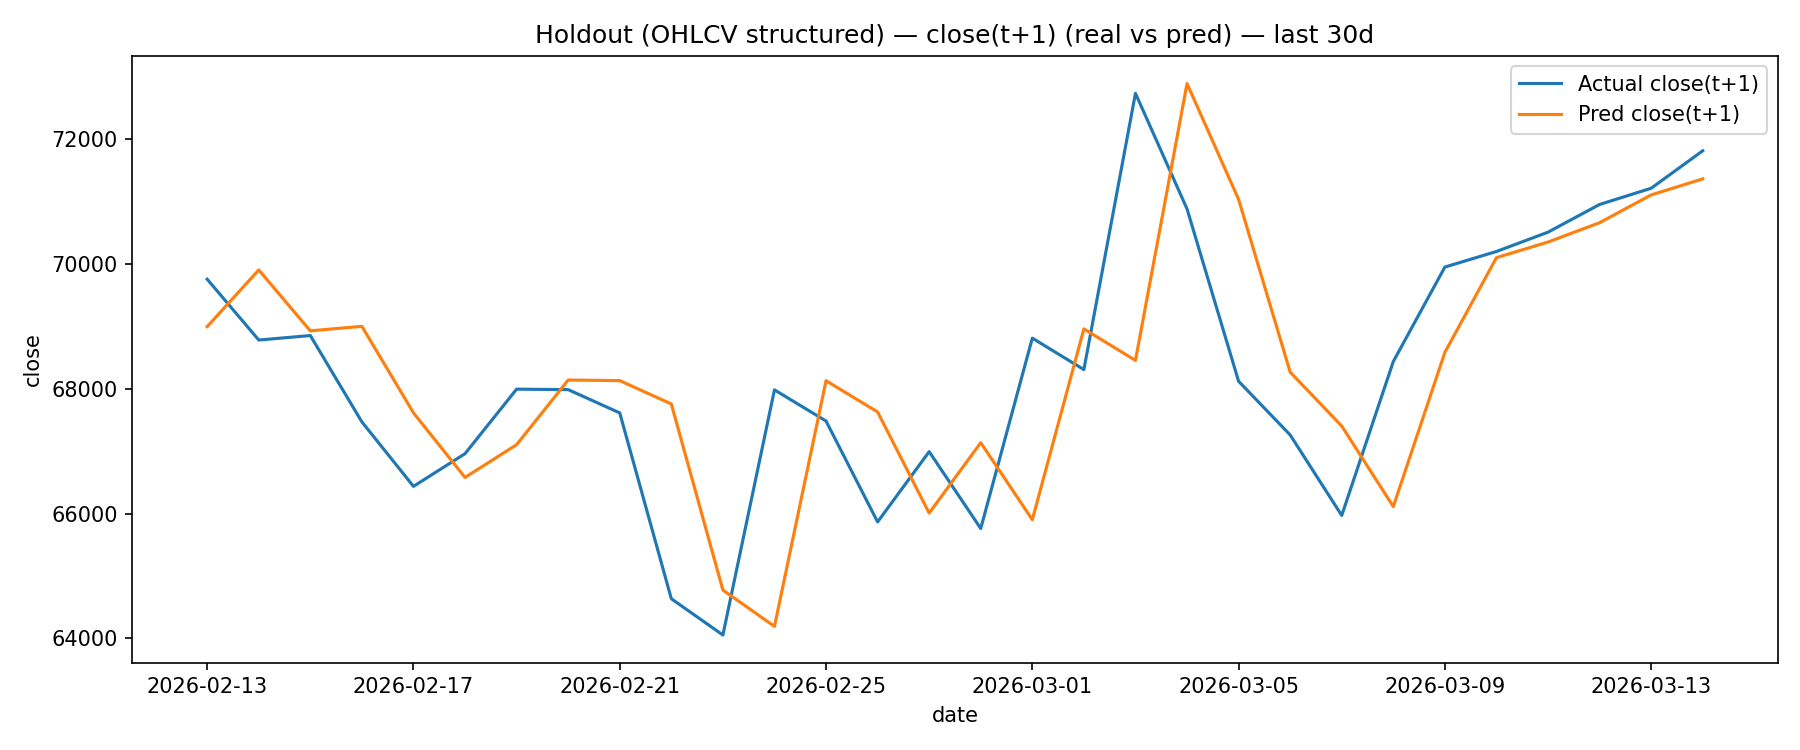

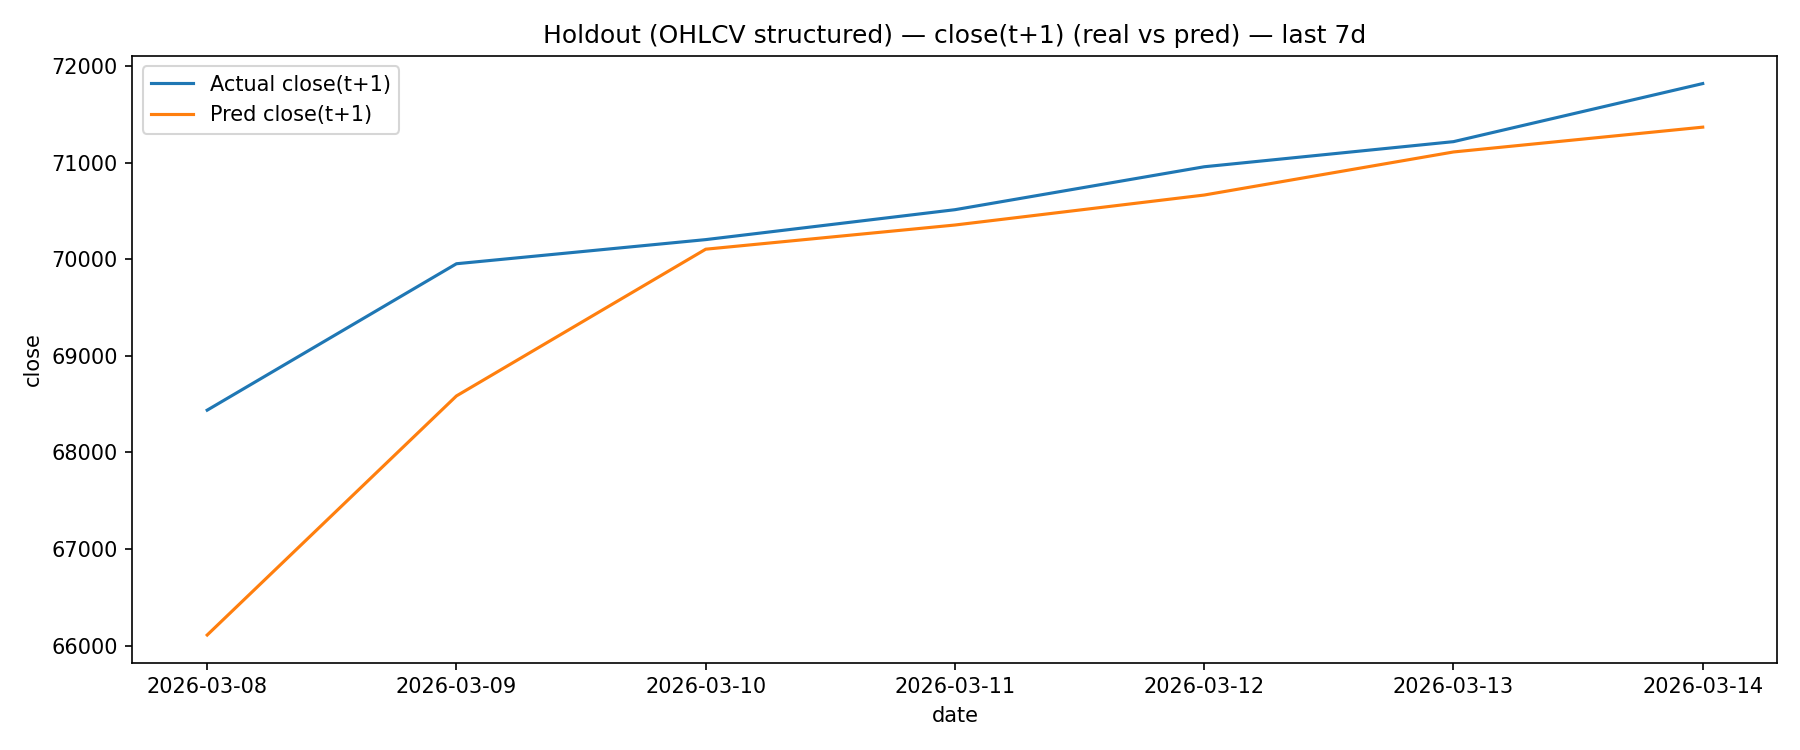

('data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_full.png',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_last30d.png',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_last7d.png',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_close_full.png',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_close_last30d.png',
 'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_holdout_close_last7d.png')

In [9]:
def plot_holdout_candles(pred: pd.DataFrame, title: str, out_path: Path, last_n: int | None = None) -> None:
    from matplotlib.patches import Rectangle

    d = pred.copy()
    if last_n is not None:
        d = d.tail(last_n)

    d = d.reset_index(drop=True)
    dates = pd.to_datetime(d["date"])
    x = np.arange(len(dates), dtype=float)

    def _plot_candles(ax, o: np.ndarray, h: np.ndarray, l: np.ndarray, c: np.ndarray, *, up: str, down: str) -> None:
        width = 0.6
        for i in range(len(o)):
            color = up if c[i] >= o[i] else down
            ax.vlines(x[i], l[i], h[i], color=color, linewidth=1.0, alpha=0.9)
            body_low = min(o[i], c[i])
            body_h = abs(c[i] - o[i])
            if body_h == 0:
                body_h = 1e-9
            ax.add_patch(
                Rectangle(
                    (x[i] - width / 2.0, body_low),
                    width,
                    body_h,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.5,
                )
            )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title)

    _plot_candles(
        ax1,
        d["y_true_open_t1"].to_numpy(dtype=float),
        d["y_true_high_t1"].to_numpy(dtype=float),
        d["y_true_low_t1"].to_numpy(dtype=float),
        d["y_true_close_t1"].to_numpy(dtype=float),
        up="#2ca02c",
        down="#d62728",
    )
    ax1.set_title("Real")
    ax1.set_ylabel("price")
    ax1.grid(True, alpha=0.2)

    _plot_candles(
        ax2,
        d["y_pred_open_t1"].to_numpy(dtype=float),
        d["y_pred_high_t1"].to_numpy(dtype=float),
        d["y_pred_low_t1"].to_numpy(dtype=float),
        d["y_pred_close_t1"].to_numpy(dtype=float),
        up="#1f77b4",
        down="#9467bd",
    )
    ax2.set_title("Predicción")
    ax2.set_ylabel("price")
    ax2.grid(True, alpha=0.2)

    labels = [str(d.date()) for d in dates]
    step = max(1, len(labels) // 10)
    ax2.set_xticks(x[::step])
    ax2.set_xticklabels(labels[::step], rotation=45, ha="right")
    ax2.set_xlabel("date")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


def plot_holdout_close_lines(pred: pd.DataFrame, title: str, out_path: Path, last_n: int | None = None) -> None:
    d = pred.copy()
    if last_n is not None:
        d = d.tail(last_n)

    plt.figure(figsize=(12, 5))
    plt.plot(d["date"], d["y_true_close_t1"], label="Actual close(t+1)")
    plt.plot(d["date"], d["y_pred_close_t1"], label="Pred close(t+1)")
    plt.title(title)
    plt.xlabel("date")
    plt.ylabel("close")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_full = OUT_DIR / "fig_holdout_full.png"
fig_last30 = OUT_DIR / "fig_holdout_last30d.png"
fig_last7 = OUT_DIR / "fig_holdout_last7d.png"

fig_close_full = OUT_DIR / "fig_holdout_close_full.png"
fig_close_last30 = OUT_DIR / "fig_holdout_close_last30d.png"
fig_close_last7 = OUT_DIR / "fig_holdout_close_last7d.png"

plot_holdout_candles(pred_holdout, "Holdout (OHLCV structured) — velas (real vs pred) — full", fig_full, last_n=None)
plot_holdout_candles(pred_holdout, "Holdout (OHLCV structured) — velas (real vs pred) — last 30d", fig_last30, last_n=30)
plot_holdout_candles(pred_holdout, "Holdout (OHLCV structured) — velas (real vs pred) — last 7d", fig_last7, last_n=7)

plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV structured) — close(t+1) (real vs pred) — full", fig_close_full, last_n=None)
plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV structured) — close(t+1) (real vs pred) — last 30d", fig_close_last30, last_n=30)
plot_holdout_close_lines(pred_holdout, "Holdout (OHLCV structured) — close(t+1) (real vs pred) — last 7d", fig_close_last7, last_n=7)

(
    to_relative(fig_full, PROJECT_ROOT),
    to_relative(fig_last30, PROJECT_ROOT),
    to_relative(fig_last7, PROJECT_ROOT),
    to_relative(fig_close_full, PROJECT_ROOT),
    to_relative(fig_close_last30, PROJECT_ROOT),
    to_relative(fig_close_last7, PROJECT_ROOT),
)

## 10) Figura timeline folds + holdout

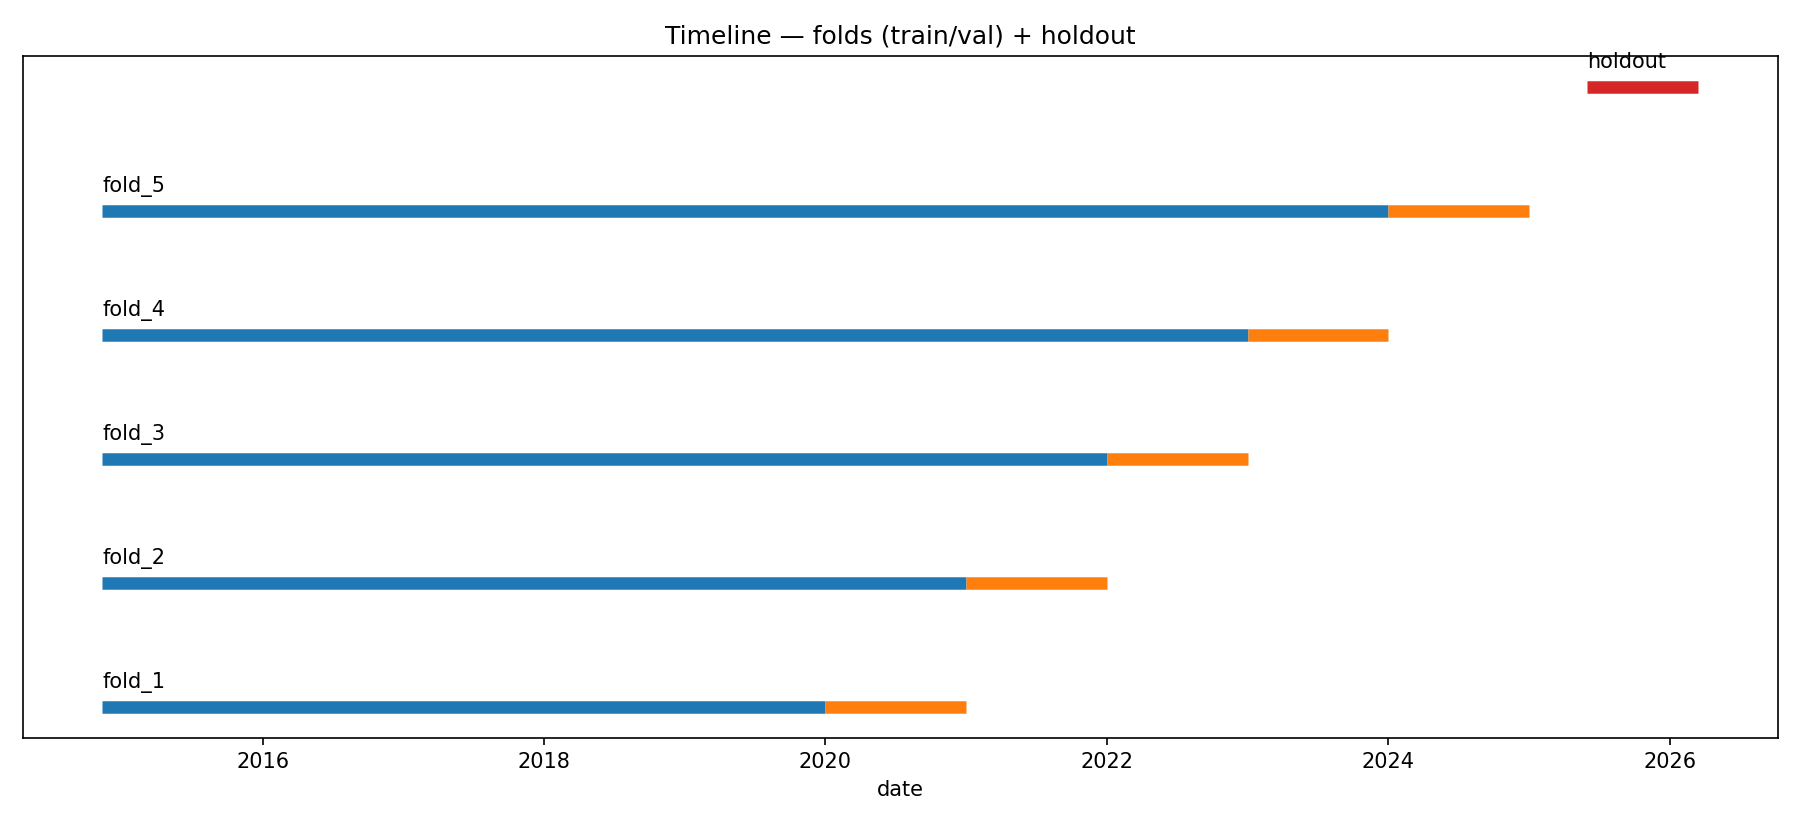

'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_timeline_folds_holdout.png'

In [10]:
def plot_timeline(folds: list[Period], holdout_start: pd.Timestamp, holdout_end: pd.Timestamp, out_path: Path) -> None:
    plt.figure(figsize=(12, 3 + 0.5 * len(folds)))

    y = 0
    for p in folds:
        plt.hlines(y, p.train_start, p.train_end, colors="#1f77b4", linewidth=6)
        plt.hlines(y, p.val_start, p.val_end, colors="#ff7f0e", linewidth=6)
        plt.text(p.train_start, y + 0.15, p.name)
        y += 1

    plt.hlines(y, holdout_start, holdout_end, colors="#d62728", linewidth=6)
    plt.text(holdout_start, y + 0.15, "holdout")

    plt.yticks([])
    plt.xlabel("date")
    plt.title("Timeline — folds (train/val) + holdout")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    display(Image(filename=str(out_path)))
    plt.close()


fig_timeline = OUT_DIR / "fig_timeline_folds_holdout.png"
plot_timeline(folds, holdout_start, holdout_end, fig_timeline)
to_relative(fig_timeline, PROJECT_ROOT)

## 11) Curva de loss (dev training)

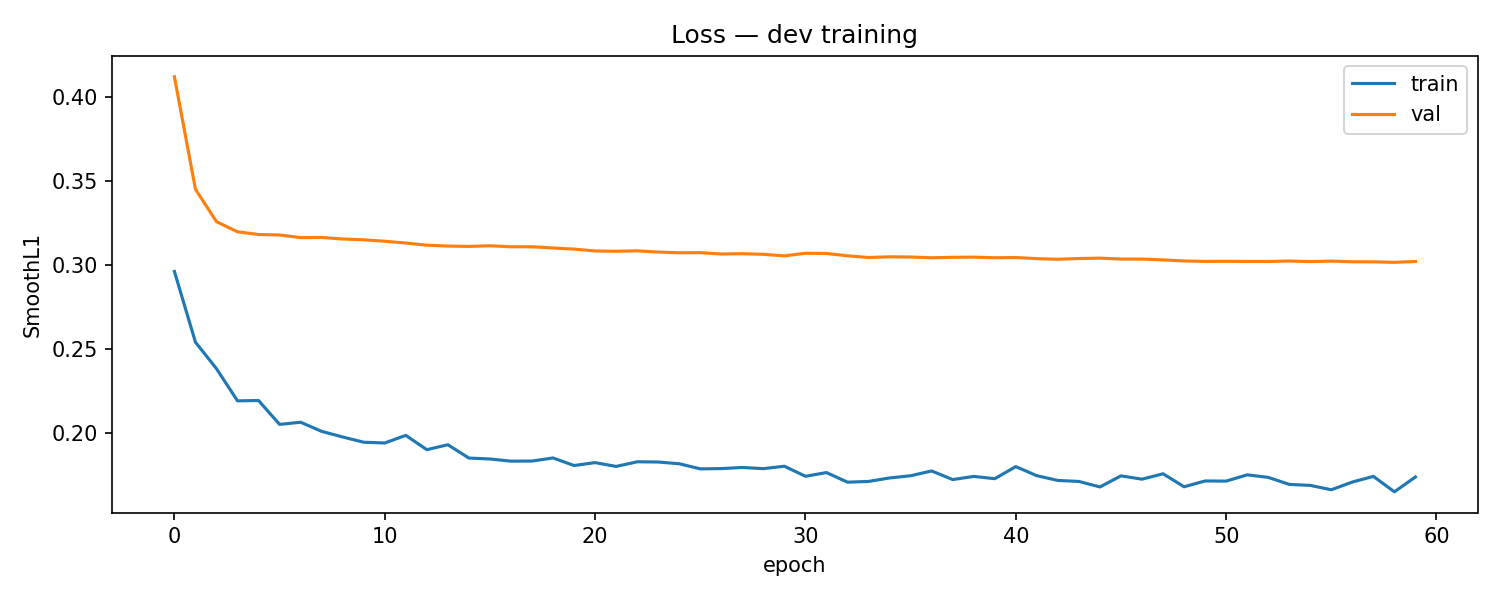

'data/_experiments/ohlcv/T1_03_transformer_encoder_structured/full/20260315_150328/fig_loss_dev.png'

In [11]:
fig_loss = OUT_DIR / "fig_loss_dev.png"

plt.figure(figsize=(10, 4))
plt.plot(history_dev["train_loss"], label="train")
plt.plot(history_dev["val_loss"], label="val")
plt.title("Loss — dev training")
plt.xlabel("epoch")
plt.ylabel("SmoothL1")
plt.legend()
plt.tight_layout()
plt.savefig(fig_loss, dpi=150)
display(Image(filename=str(fig_loss)))
plt.close()

to_relative(fig_loss, PROJECT_ROOT)

In [ ]:
import textwrap
from pathlib import Path


def export_architecture_png(model, out_path: Path):
    arch_text = str(model)
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(12, 8))
    plt.axis("off")
    plt.text(
        0.01,
        0.99,
        arch_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=10,
        linespacing=1.15,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close()
    return out_path


tfm_arch_fig = (PROJECT_ROOT / "figuras" / "modelo" / "fig_9_1_arquitectura_modelo_e3.png")
export_architecture_png(model_dev, tfm_arch_fig)
to_relative(tfm_arch_fig, PROJECT_ROOT)